# Q1: Eikonal Equation on the Square [-1,1]^2

Solving ||grad u||^2 - 1 = 0 with u=0 on the boundary. The true solution is the distance to the boundary.

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import equinox as eqx
import optax
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", False)
key = jrandom.PRNGKey(42)
print(f"JAX devices: {jax.devices()}")

JAX devices: [CudaDevice(id=0)]


## Domain setup and exact solution

On the square [-1,1]^2 the distance to boundary is min(1+x, 1-x, 1+y, 1-y).

In [2]:
def exact_solution(xy):
    x, y = xy[0], xy[1]
    return jnp.min(jnp.array([1.0+x, 1.0-x, 1.0+y, 1.0-y]))

def sample_interior(key, n):
    return jrandom.uniform(key, (n, 2), minval=-1.0, maxval=1.0)

def sample_boundary(key, n):
    n_per_edge = n // 4
    keys = jrandom.split(key, 4)
    t0 = jrandom.uniform(keys[0], (n_per_edge,), minval=-1, maxval=1)
    t1 = jrandom.uniform(keys[1], (n_per_edge,), minval=-1, maxval=1)
    t2 = jrandom.uniform(keys[2], (n_per_edge,), minval=-1, maxval=1)
    t3 = jrandom.uniform(keys[3], (n_per_edge,), minval=-1, maxval=1)
    bottom = jnp.stack([t0, -jnp.ones(n_per_edge)], axis=1)
    top    = jnp.stack([t1,  jnp.ones(n_per_edge)], axis=1)
    left   = jnp.stack([-jnp.ones(n_per_edge), t2], axis=1)
    right  = jnp.stack([ jnp.ones(n_per_edge), t3], axis=1)
    return jnp.concatenate([bottom, top, left, right], axis=0)

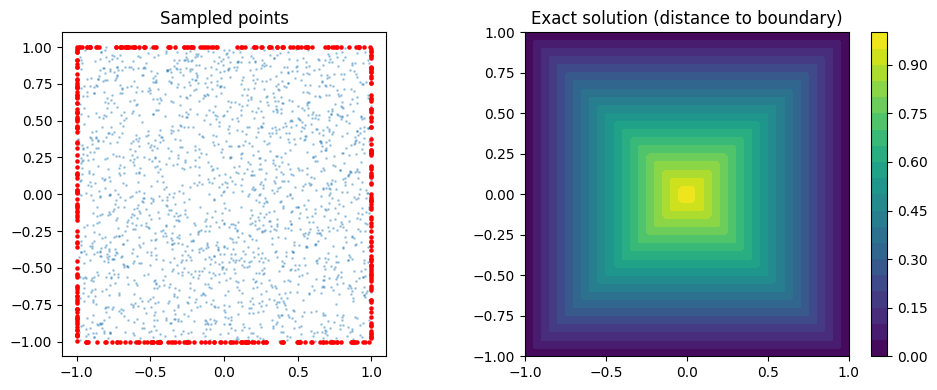

In [3]:
# Quick sanity check: sample and visualize
k1, k2, key = jrandom.split(key, 3)
x_int = sample_interior(k1, 2000)
x_bnd = sample_boundary(k2, 400)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(x_int[:,0], x_int[:,1], s=1, alpha=0.3)
axes[0].scatter(x_bnd[:,0], x_bnd[:,1], s=5, c='red')
axes[0].set_aspect('equal'); axes[0].set_title('Sampled points')

# Plot exact solution on a grid
xg = jnp.linspace(-1, 1, 100)
yg = jnp.linspace(-1, 1, 100)
X, Y = jnp.meshgrid(xg, yg)
XY = jnp.stack([X.ravel(), Y.ravel()], axis=1)
U_exact = jax.vmap(exact_solution)(XY).reshape(100, 100)
c = axes[1].contourf(X, Y, U_exact, levels=20, cmap='viridis')
plt.colorbar(c, ax=axes[1])
axes[1].set_aspect('equal'); axes[1].set_title('Exact solution (distance to boundary)')
plt.tight_layout(); plt.show()

## Model definition

I'll use hard boundary conditions: u(x,y) = (1-x^2)(1-y^2) * NN(x,y). This guarantees u=0 on all edges.

In [4]:
class EikonalPINN2D(eqx.Module):
    mlp: eqx.nn.MLP
    hard_bc: bool = eqx.field(static=True)

    def __call__(self, xy):
        out = self.mlp(xy)
        out = jnp.squeeze(out, axis=-1)
        if self.hard_bc:
            x, y = xy[0], xy[1]
            phi = (1.0 - x**2) * (1.0 - y**2)
            out = phi * out
        return out

def make_model(key, hard_bc=True, width=64, depth=4):
    mlp = eqx.nn.MLP(
        in_size=2, out_size=1, width_size=width,
        depth=depth, activation=jnp.tanh, key=key
    )
    return EikonalPINN2D(mlp=mlp, hard_bc=hard_bc)

In [5]:
# Quick test: model outputs the right shape, and is zero on boundary
k1, key = jrandom.split(key)
test_model = make_model(k1, hard_bc=True)

print("Interior point:", test_model(jnp.array([0.3, 0.5])))
print("Boundary point (edge):", test_model(jnp.array([1.0, 0.5])))
print("Boundary point (corner):", test_model(jnp.array([1.0, 1.0])))

Interior point: -0.04104377
Boundary point (edge): -0.0
Boundary point (corner): -0.0


## PDE residual

Eikonal: ||grad u||^2 - 1 = 0. With viscosity: ||grad u||^2 - 1 - eps * laplacian(u) = 0.

In [6]:
def pde_residual(model, xy, epsilon=0.0):
    def u_fn(xy):
        return model(xy)
    grad_u = jax.grad(u_fn)(xy)        # [du/dx, du/dy]
    grad_norm_sq = jnp.sum(grad_u**2)  # ||grad u||^2
    # Laplacian = d2u/dx2 + d2u/dy2
    hess = jax.hessian(u_fn)(xy)       # 2x2 Hessian
    laplacian = hess[0, 0] + hess[1, 1]
    return grad_norm_sq - 1.0 - epsilon * laplacian

In [7]:
# Test residual computation on a single point
test_xy = jnp.array([0.3, 0.5])
res = pde_residual(test_model, test_xy, epsilon=0.0)
print(f"Residual at (0.3, 0.5): {res:.4f}")

# Test vmapped residual
batch_res = jax.vmap(lambda xy: pde_residual(test_model, xy, 0.0))(x_int[:5])
print(f"Batch residuals: {batch_res}")

Residual at (0.3, 0.5): -0.9978


Batch residuals: [-0.9979572  -0.99353707 -0.99959195 -0.9972253  -0.99467874]


## Training loop

Let me start with a basic training loop using hard BC. Just PDE residual loss since boundary is enforced.

In [8]:
def make_loss_fn(n_interior, epsilon=0.0, hard_bc=True, n_boundary=200):
    def loss_fn(model, key):
        k1, k2 = jrandom.split(key)
        x_i = sample_interior(k1, n_interior)
        res = jax.vmap(lambda xy: pde_residual(model, xy, epsilon))(x_i)
        loss_pde = jnp.mean(res**2)
        loss_bc = 0.0
        if not hard_bc:
            x_b = sample_boundary(k2, n_boundary)
            u_b = jax.vmap(model)(x_b)
            loss_bc = jnp.mean(u_b**2)
        return loss_pde + 10.0 * loss_bc, (loss_pde, loss_bc)
    return loss_fn

In [9]:
def train(model, steps, lr=1e-3, n_interior=2048, epsilon=0.0,
          hard_bc=True, n_boundary=200, seed=0, log_every=500):
    loss_fn = make_loss_fn(n_interior, epsilon, hard_bc, n_boundary)
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))
    loss_and_grad = eqx.filter_jit(eqx.filter_value_and_grad(loss_fn, has_aux=True))

    @eqx.filter_jit
    def step(model, opt_state, key):
        (loss, aux), grads = loss_and_grad(model, key)
        updates, opt_state = optimizer.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss, aux

    key = jrandom.PRNGKey(seed)
    history = []
    for i in range(1, steps + 1):
        key, sk = jrandom.split(key)
        model, opt_state, loss, (l_pde, l_bc) = step(model, opt_state, sk)
        history.append(float(loss))
        if i % log_every == 0 or i == 1:
            print(f"  step {i:5d} | loss={loss:.3e} | pde={l_pde:.3e} | bc={l_bc:.3e}")
    return model, history

Let me do a quick test: 100 steps to make sure everything compiles and runs.

In [10]:
k1, key = jrandom.split(key)
model_test = make_model(k1, hard_bc=True)
model_test, hist_test = train(model_test, steps=100, lr=1e-3, log_every=50)

  step     1 | loss=9.087e-01 | pde=9.087e-01 | bc=0.000e+00
  step    50 | loss=2.154e-01 | pde=2.154e-01 | bc=0.000e+00


  step   100 | loss=1.615e-01 | pde=1.615e-01 | bc=0.000e+00


## Evaluation helpers

In [11]:
def eval_on_grid(model, n=100):
    xg = jnp.linspace(-1, 1, n)
    yg = jnp.linspace(-1, 1, n)
    X, Y = jnp.meshgrid(xg, yg)
    XY = jnp.stack([X.ravel(), Y.ravel()], axis=1)
    U_pred = jax.vmap(model)(XY).reshape(n, n)
    U_true = jax.vmap(exact_solution)(XY).reshape(n, n)
    return X, Y, U_pred, U_true

def plot_comparison(model, title=""):
    X, Y, U_pred, U_true = eval_on_grid(model)
    err = jnp.abs(U_pred - U_true)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    c0 = axes[0].contourf(X, Y, U_pred, levels=20, cmap='viridis')
    plt.colorbar(c0, ax=axes[0]); axes[0].set_title('Predicted u')
    c1 = axes[1].contourf(X, Y, U_true, levels=20, cmap='viridis')
    plt.colorbar(c1, ax=axes[1]); axes[1].set_title('Exact u')
    c2 = axes[2].contourf(X, Y, err, levels=20, cmap='hot')
    plt.colorbar(c2, ax=axes[2]); axes[2].set_title(f'|Error| (mean={float(err.mean()):.4f})')
    for ax in axes: ax.set_aspect('equal')
    if title: fig.suptitle(title)
    plt.tight_layout(); plt.show()
    return float(err.mean()), float(err.max())

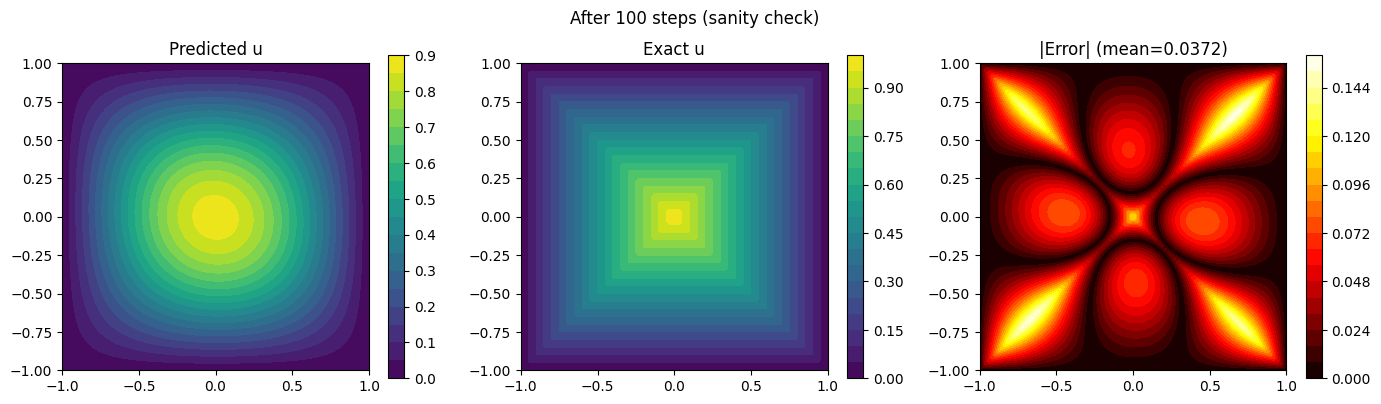

Mean error: 0.0372, Max error: 0.1581


In [12]:
# Check the quick test model
mean_err, max_err = plot_comparison(model_test, "After 100 steps (sanity check)")
print(f"Mean error: {mean_err:.4f}, Max error: {max_err:.4f}")

## Vanilla hard-BC training (eps=0)

Let me try the unregularized equation directly with more steps.

In [13]:
k1, key = jrandom.split(key)
model_v = make_model(k1, hard_bc=True, width=64, depth=4)
model_v, hist_v = train(model_v, steps=5000, lr=1e-3, n_interior=2048, epsilon=0.0, log_every=1000)

  step     1 | loss=9.866e-01 | pde=9.866e-01 | bc=0.000e+00


  step  1000 | loss=3.629e-02 | pde=3.629e-02 | bc=0.000e+00


  step  2000 | loss=3.363e-02 | pde=3.363e-02 | bc=0.000e+00


  step  3000 | loss=2.595e-02 | pde=2.595e-02 | bc=0.000e+00


  step  4000 | loss=2.071e-02 | pde=2.071e-02 | bc=0.000e+00


  step  5000 | loss=1.190e-02 | pde=1.190e-02 | bc=0.000e+00


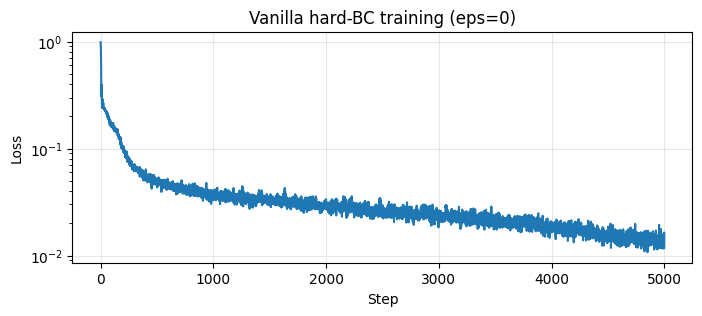

In [14]:
plt.figure(figsize=(8, 3))
plt.plot(hist_v)
plt.yscale('log'); plt.xlabel('Step'); plt.ylabel('Loss')
plt.title('Vanilla hard-BC training (eps=0)'); plt.grid(True, alpha=0.3)
plt.show()

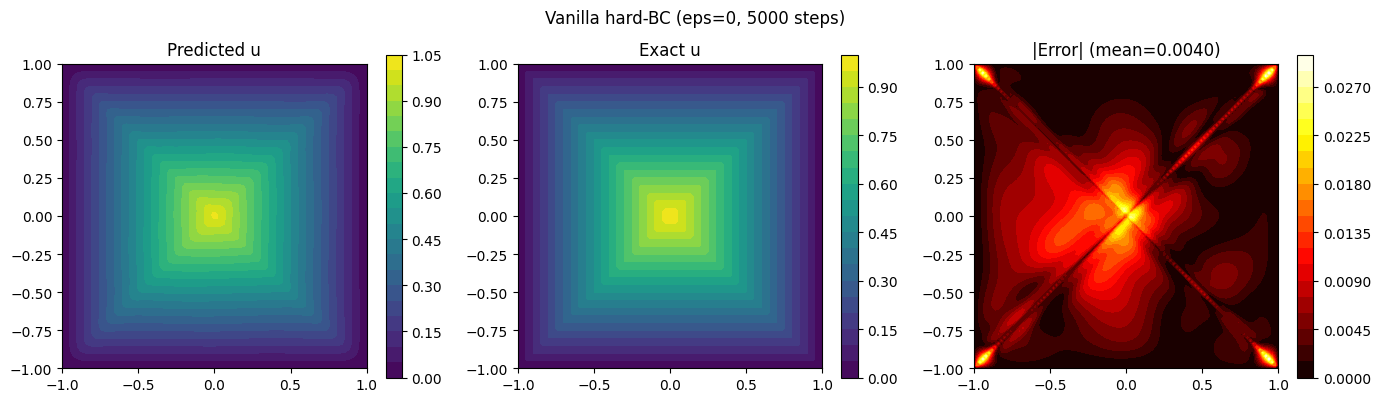

Mean error: 0.0040, Max error: 0.0297


In [15]:
mean_err, max_err = plot_comparison(model_v, "Vanilla hard-BC (eps=0, 5000 steps)")
print(f"Mean error: {mean_err:.4f}, Max error: {max_err:.4f}")

## Curriculum learning (viscous annealing)

The vanilla approach may struggle with the non-smooth kink along the diagonals. Let me anneal epsilon from large to ~0 and warm-start each stage.

In [16]:
eps_schedule = [1.0, 0.3, 0.1, 0.03, 0.01, 0.003, 0.0]
steps_per_stage = 3000

k1, key = jrandom.split(key)
model_c = make_model(k1, hard_bc=True, width=64, depth=4)
all_hist = []
stage_models = []

for eps in eps_schedule:
    print(f"\n=== Stage eps={eps} ===")
    model_c, hist = train(model_c, steps=steps_per_stage, lr=1e-3,
                          n_interior=2048, epsilon=eps, log_every=1000)
    all_hist.extend([(eps, l) for l in hist])
    stage_models.append((eps, model_c))


=== Stage eps=1.0 ===


  step     1 | loss=1.436e+00 | pde=1.436e+00 | bc=0.000e+00


  step  1000 | loss=1.296e-02 | pde=1.296e-02 | bc=0.000e+00


  step  2000 | loss=1.657e-02 | pde=1.657e-02 | bc=0.000e+00


  step  3000 | loss=1.048e-02 | pde=1.048e-02 | bc=0.000e+00

=== Stage eps=0.3 ===


...

  step  3000 | loss=9.216e-03 | pde=9.216e-03 | bc=0.000e+00

=== Stage eps=0.0 ===


  step     1 | loss=1.121e-02 | pde=1.121e-02 | bc=0.000e+00


  step  1000 | loss=7.813e-03 | pde=7.813e-03 | bc=0.000e+00


  step  2000 | loss=8.362e-03 | pde=8.362e-03 | bc=0.000e+00


  step  3000 | loss=6.027e-03 | pde=6.027e-03 | bc=0.000e+00


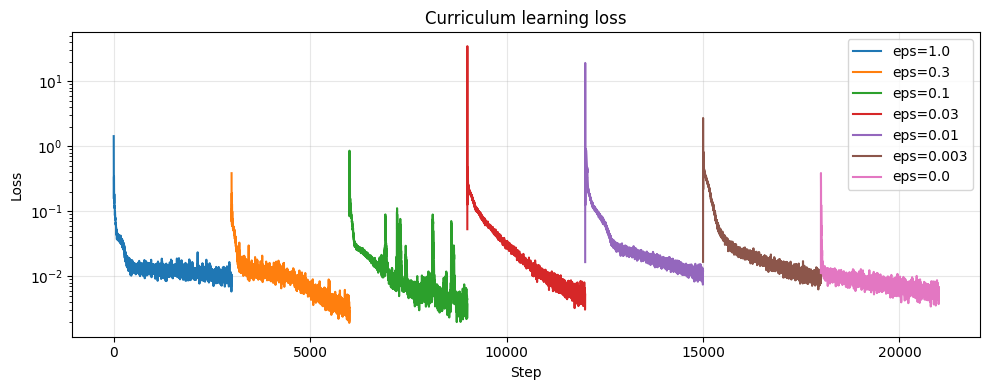

In [17]:
# Loss curve colored by stage
fig, ax = plt.subplots(figsize=(10, 4))
prev_eps = None; start = 0
for i, (eps, l) in enumerate(all_hist):
    if eps != prev_eps:
        if prev_eps is not None:
            losses = [v for _, v in all_hist[start:i]]
            ax.plot(range(start, i), losses, label=f'eps={prev_eps}')
        start = i; prev_eps = eps
losses = [v for _, v in all_hist[start:]]
ax.plot(range(start, len(all_hist)), losses, label=f'eps={prev_eps}')
ax.set_yscale('log'); ax.set_xlabel('Step'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title('Curriculum learning loss'); plt.tight_layout(); plt.show()

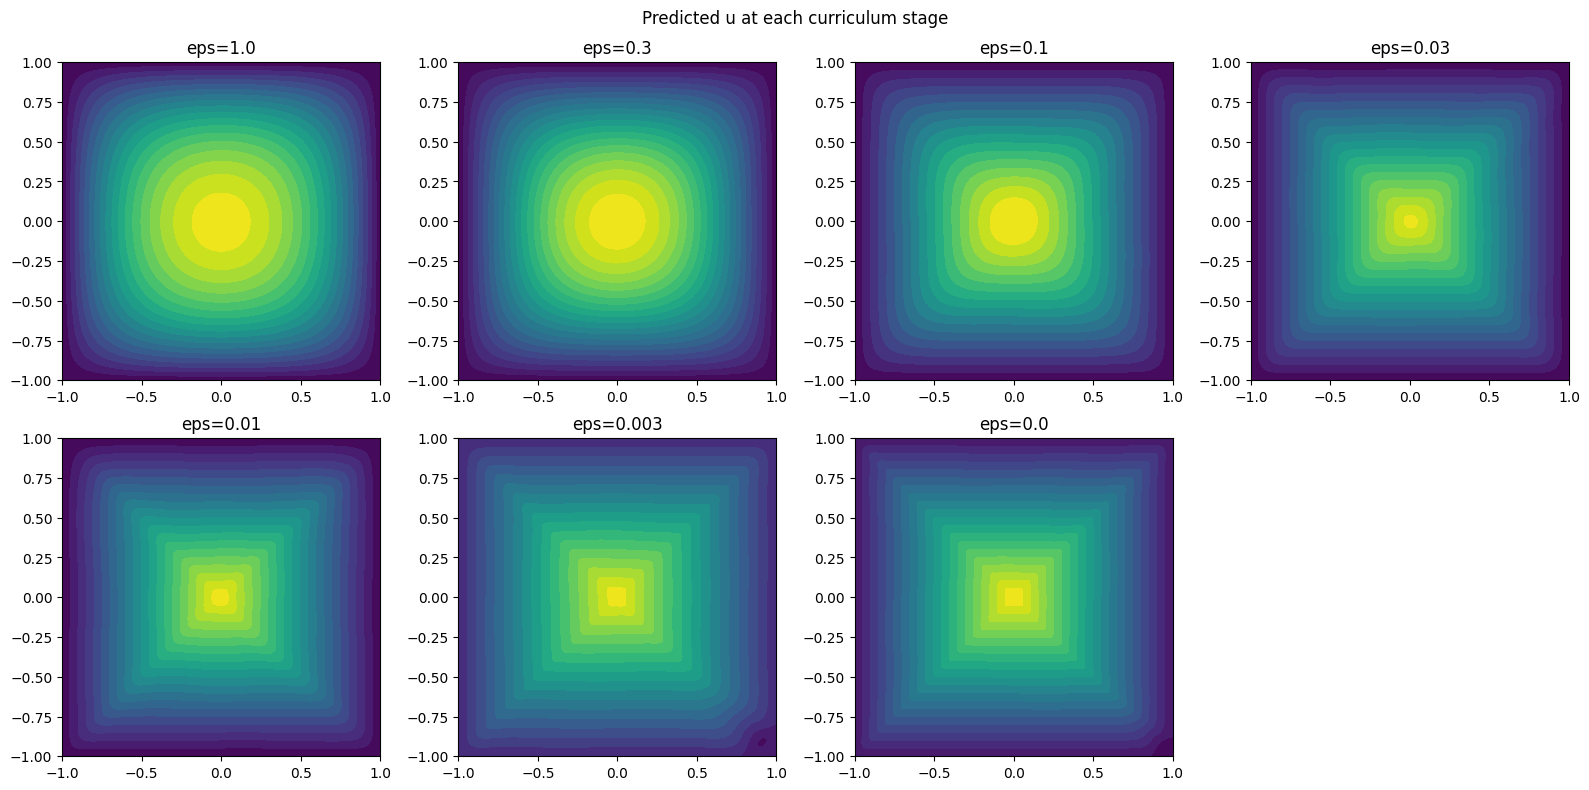

In [18]:
# Show solution at each stage
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for idx, (eps, m) in enumerate(stage_models):
    X, Y, U_pred, U_true = eval_on_grid(m)
    row, col = idx // 4, idx % 4
    c = axes[row, col].contourf(X, Y, U_pred, levels=20, cmap='viridis')
    axes[row, col].set_title(f'eps={eps}')
    axes[row, col].set_aspect('equal')
# hide unused subplot
axes[1, 3].axis('off')
plt.suptitle('Predicted u at each curriculum stage')
plt.tight_layout(); plt.show()

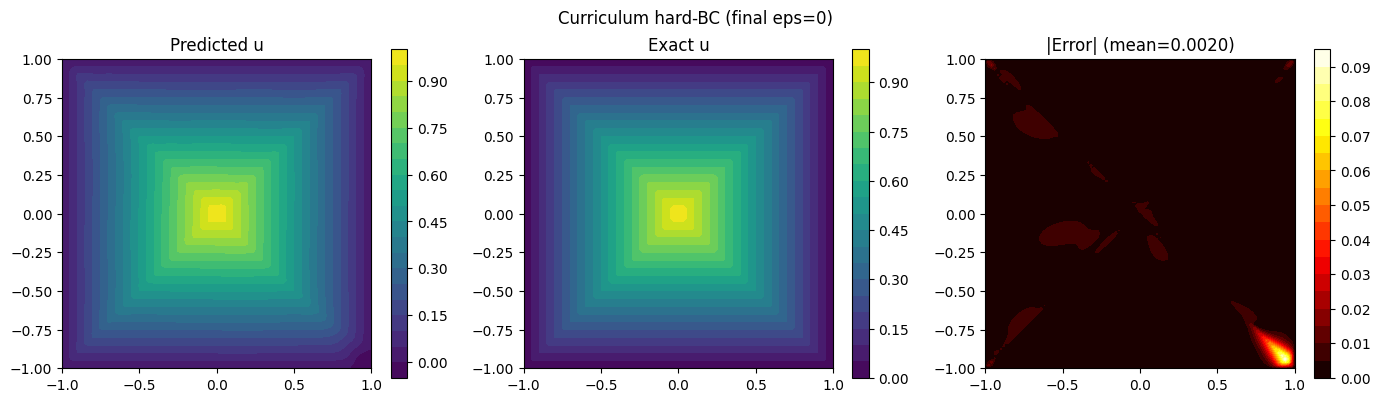

Mean error: 0.0020, Max error: 0.0937


In [19]:
# Final curriculum model evaluation
mean_err, max_err = plot_comparison(model_c, "Curriculum hard-BC (final eps=0)")
print(f"Mean error: {mean_err:.4f}, Max error: {max_err:.4f}")

## Comparison: vanilla vs curriculum

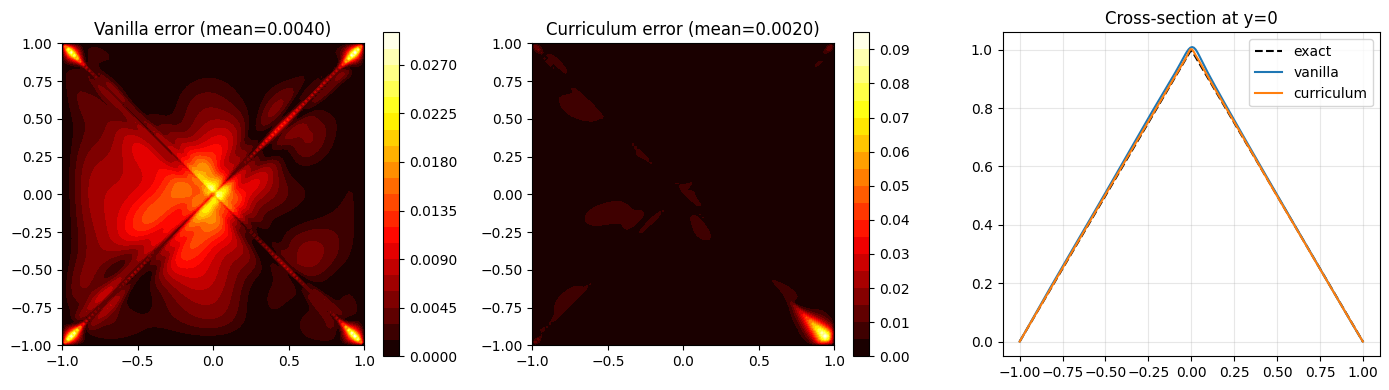

In [20]:
X, Y, Uv, Ut = eval_on_grid(model_v)
_, _, Uc, _ = eval_on_grid(model_c)
err_v = jnp.abs(Uv - Ut)
err_c = jnp.abs(Uc - Ut)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
c0 = axes[0].contourf(X, Y, err_v, levels=20, cmap='hot')
plt.colorbar(c0, ax=axes[0]); axes[0].set_title(f'Vanilla error (mean={float(err_v.mean()):.4f})')
c1 = axes[1].contourf(X, Y, err_c, levels=20, cmap='hot')
plt.colorbar(c1, ax=axes[1]); axes[1].set_title(f'Curriculum error (mean={float(err_c.mean()):.4f})')
# Cross-section along y=0
xline = jnp.linspace(-1, 1, 200)
xy_line = jnp.stack([xline, jnp.zeros_like(xline)], axis=1)
uv_line = jax.vmap(model_v)(xy_line)
uc_line = jax.vmap(model_c)(xy_line)
ut_line = jax.vmap(exact_solution)(xy_line)
axes[2].plot(xline, ut_line, 'k--', label='exact')
axes[2].plot(xline, uv_line, label='vanilla')
axes[2].plot(xline, uc_line, label='curriculum')
axes[2].legend(); axes[2].set_title('Cross-section at y=0')
axes[2].grid(True, alpha=0.3)
for ax in axes[:2]: ax.set_aspect('equal')
plt.tight_layout(); plt.show()

The curriculum approach should handle the ridge along the diagonals much better than the vanilla approach, which tends to smooth it out.